# **B**ell-**L**inking **a**nd **R**emote **T**eleportation: A **SABRE** heuristic search algorithm (BLaRTSABRE)

## How to use BLaRT architecture

For example, 2 IBM Tokyo (20 qubits) quantum devices can be constructed as follows:

In [12]:
from blart_architecture import BLARTNetworkGraph

def tokyo_edges(offset=0):
    edges = []

    # 4 horizontal chains: 0-1-2-3-4, 5-6-7-8-9, 10-11-12-13-14, 15-16-17-18-19
    for start in (0, 5, 10, 15):
        for i in range(start, start + 4):
            edges.append((i + offset, i + 1 + offset))

    # vertical links i <-> i+5 for i = 0..14
    for i in range(0, 15):
        edges.append((i + offset, i + 5 + offset))

    # diagonals
    for i in (1, 3, 5, 7, 11, 13):
        edges.append((i + offset, i + 6 + offset))

    for i in (2, 4, 6, 8, 12, 14):
        edges.append((i + offset, i + 4 + offset))

    return edges

@staticmethod
def blart_two_tokyo():
    data_edges = []
    data_edges += tokyo_edges(offset=0)
    data_edges += tokyo_edges(offset=20)

    blart_edge_groups = [
        ([9, 4],  [20, 21]),   # group 0: 0a side, 0b side
        ([14, 19], [24, 23]),  # group 1: 1a side, 1b side
    ]

    return BLARTNetworkGraph(
        data_edges,
        blart_edge_groups=blart_edge_groups,
        name="Two connected IBM Q Tokyo BLART (40 qubits, 2 corees)"
    )

and can be visualised as follows:

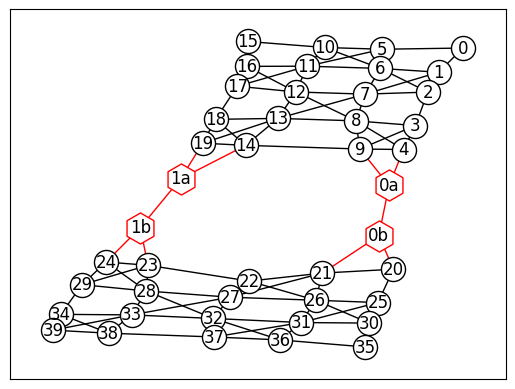

In [14]:
blart_two_tokyo().draw()

BLaRT architecture can be created as grid as shown below:

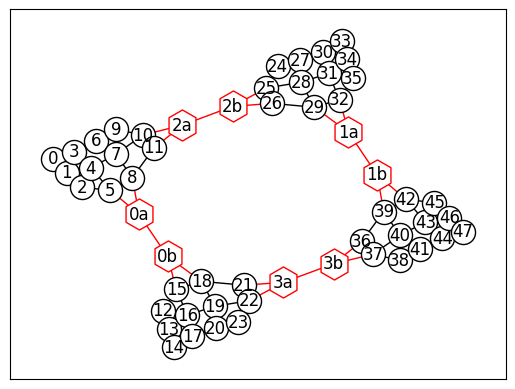

In [19]:
from blart_architecture import blart_grid

arch = blart_grid(4, 3, 2, 2)
arch.draw()

## How to use BLaRTSABRE

For example, 25 qubits QFT can be mapped and routed on a 48 qubits BLaRT architecture (4 cores, 12 qubits per core) as follows:

In [21]:
from mapper.blartsabre import blartsabre_layout
from blart_architecture import blart_grid

from qiskit import QuantumCircuit
from decompose import init_circuit

qc = QuantumCircuit.from_qasm_file("./data/telesabre/qasm_25/qft_nativegates_ibm_qiskit_opt3_25.qasm")
init_cir = init_circuit(qc)

arch = blart_grid(4,3,2,2)

mapping, execution_log, total_gates, local_swaps, remote_swaps, telegates = blartsabre_layout(
    arch, init_cir, 
    verbose=True, 
    return_log=True, 
    seed=42, 
    num_iterations=5
    )

Iteration 0 ran successfully
Iteration 1 ran successfully
Iteration 2 ran successfully
Iteration 3 ran successfully
Iteration 4 ran successfully
Best Iteration:
#1426 total gates
#128 inserted SWAPs
#123 inserted Remote SWAPs
#70 Gates executed Remotely

Initial Mapping:
Logical Qubit 0: Physical Qubit 37
Logical Qubit 1: Physical Qubit 44
Logical Qubit 2: Physical Qubit 22
Logical Qubit 3: Physical Qubit 40
Logical Qubit 4: Physical Qubit 28
Logical Qubit 5: Physical Qubit 42
Logical Qubit 6: Physical Qubit 31
Logical Qubit 7: Physical Qubit 32
Logical Qubit 8: Physical Qubit 36
Logical Qubit 9: Physical Qubit 29
Logical Qubit 10: Physical Qubit 39
Logical Qubit 11: Physical Qubit 15
Logical Qubit 12: Physical Qubit 9
Logical Qubit 13: Physical Qubit 26
Logical Qubit 14: Physical Qubit 25
Logical Qubit 15: Physical Qubit 10
Logical Qubit 16: Physical Qubit 4
Logical Qubit 17: Physical Qubit 6
Logical Qubit 18: Physical Qubit 11
Logical Qubit 19: Physical Qubit 7
Logical Qubit 20: Phys